In [1]:
import pandas as pd 
import numpy as np 


# Customer Churn Analysis

## Objective
The goal of this analysis is to understand factors contributing to customer churn and identify patterns that can help improve customer retention.

## Dataset Overview

The dataset contains customer information including demographics, account details, and service usage.

Number of rows: 7043  
Number of columns: 21  

Target variable: `Churn` 

In [2]:
df = pd.read_csv("../data/raw/Telco_Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.shape

(7043, 21)

In [6]:
df.drop("customerID",axis=1,inplace=True)

In [7]:
df["TotalCharges"]= pd.to_numeric(df["TotalCharges"],errors="coerce")
df= df.dropna()
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(22)

### Data Cleaning Steps
- Verified the Null value counts and Duplicate Counts. 
- Converted `TotalCharges` to numeric
- Removed duplicate records
- Handled missing values by dropping them as they are significantly smaller in numbers. 

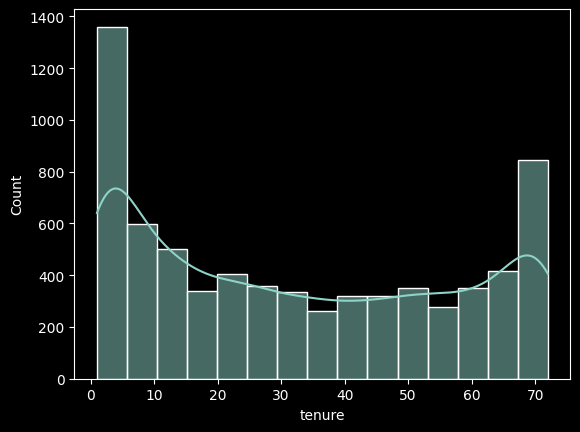

In [9]:
import seaborn as sns 
import matplotlib.pyplot as plt
plt.style.use('dark_background')
sns.histplot(df['tenure'],kde=True)
plt.show() 

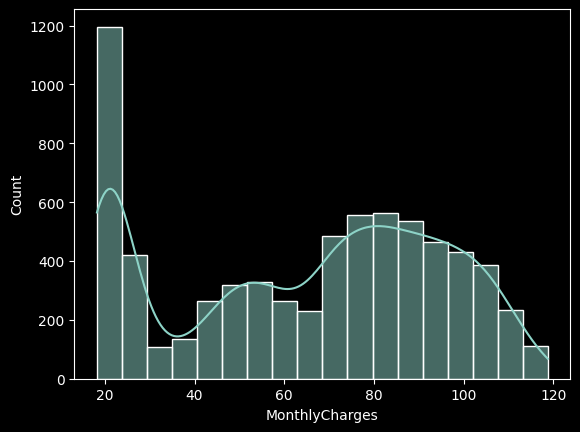

In [10]:
sns.histplot(df["MonthlyCharges"], kde=True)
plt.show() 

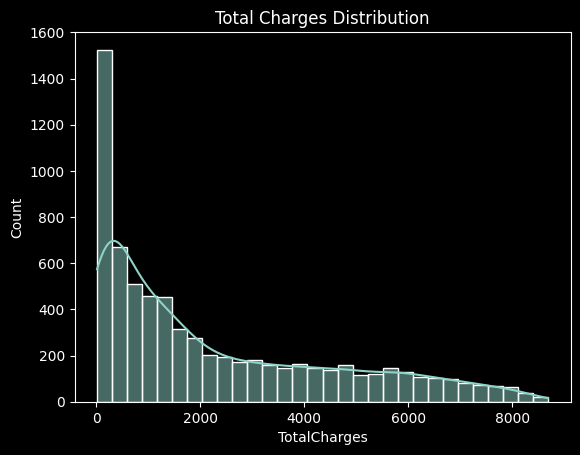

In [11]:
sns.histplot(df['TotalCharges'], bins=30, kde=True)
plt.title("Total Charges Distribution")
plt.show()  

<Axes: xlabel='MonthlyCharges'>

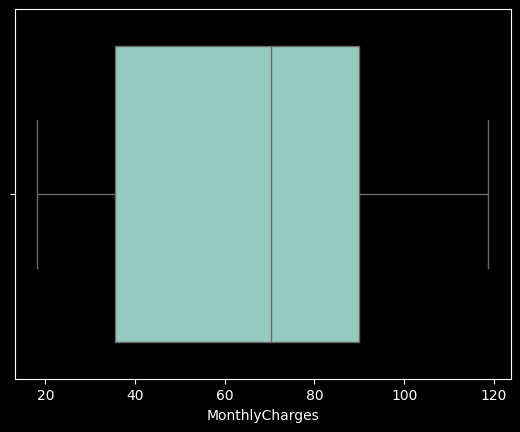

In [12]:
sns.boxplot(x=df["MonthlyCharges"])

<Axes: xlabel='tenure'>

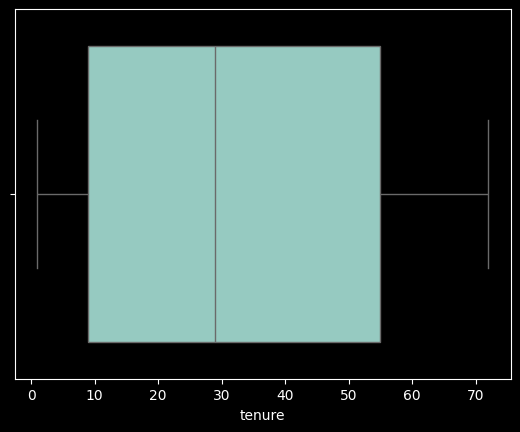

In [13]:
sns.boxplot(x=df["tenure"])

<Axes: xlabel='TotalCharges'>

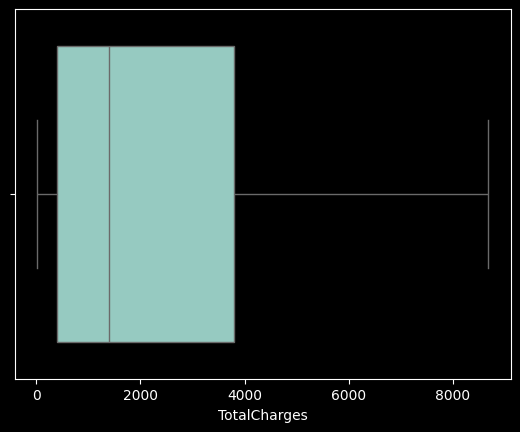

In [14]:
sns.boxplot(x=df["TotalCharges"])

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

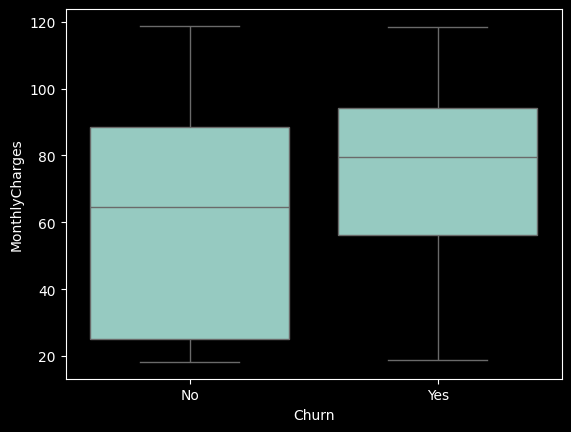

In [15]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df) 


<Axes: xlabel='Churn', ylabel='tenure'>

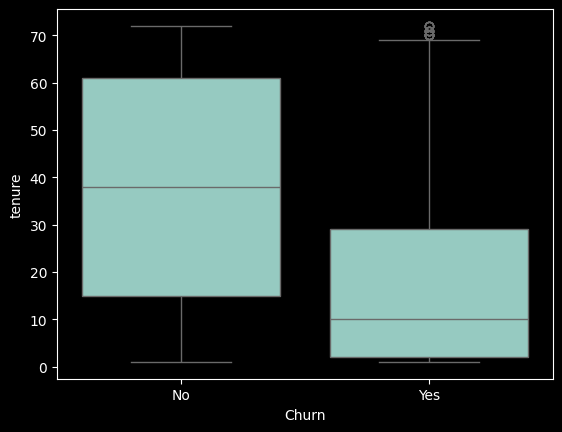

In [16]:
sns.boxplot(x="Churn", y="tenure", data=df) 

C:\Users\manik\AppData\Local\Temp\ipykernel_20816\510689950.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:w'` for the same effect.

  sns.countplot(x='InternetService', hue="Churn", data=df,color='w')


<Axes: xlabel='InternetService', ylabel='count'>

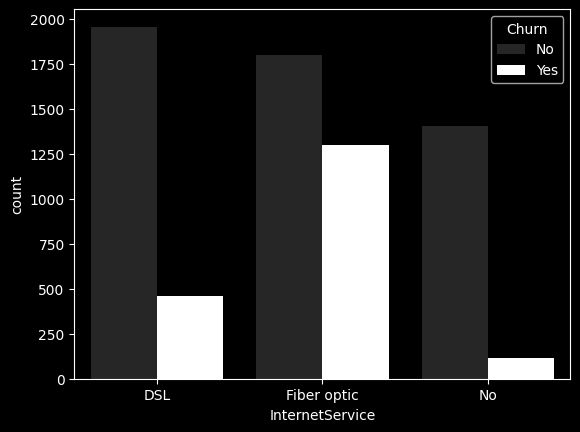

In [17]:
sns.countplot(x='InternetService', hue="Churn", data=df,color='w') 

<Axes: xlabel='PaymentMethod', ylabel='count'>

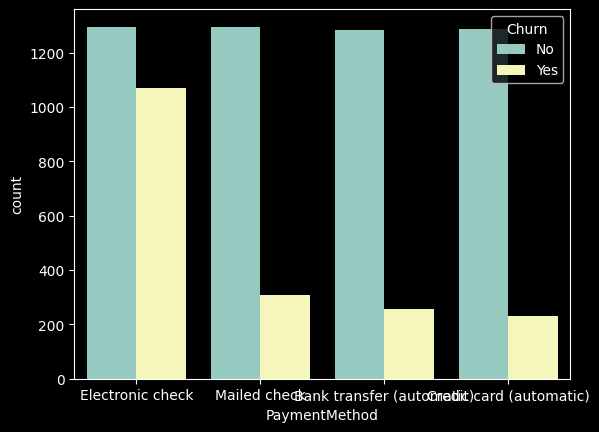

In [18]:
sns.countplot(x='PaymentMethod',hue='Churn',data=df) 

<Axes: xlabel='SeniorCitizen', ylabel='count'>

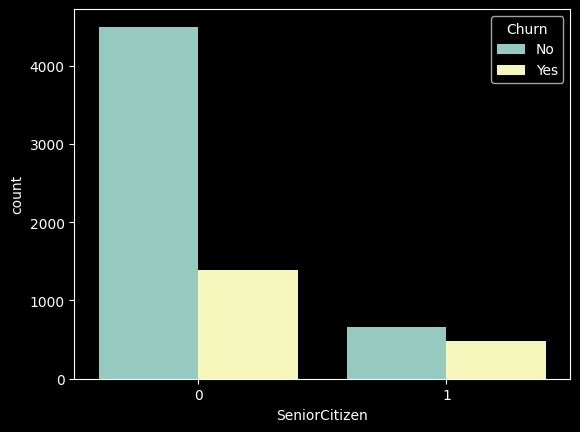

In [19]:
sns.countplot(x='SeniorCitizen',hue='Churn',data=df) 

<Axes: xlabel='Dependents', ylabel='count'>

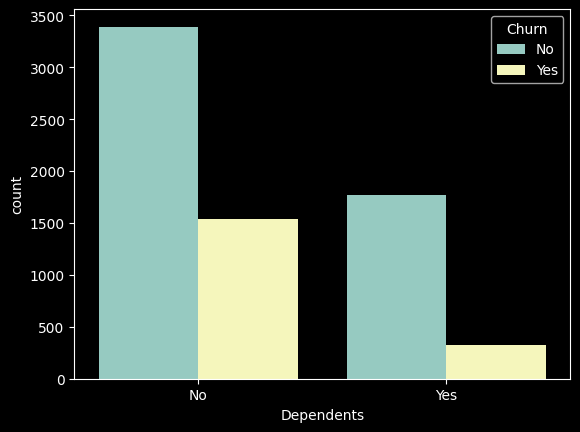

In [20]:
sns.countplot(x='Dependents',hue='Churn',data=df) 

## Observations

- Most of the people opted for a short time subscription and moderate no of people opted for a longest duration subscription.
- Month-to-month contracts show the highest churn rate.
- Customers with low tenure churn more.
- Higher monthly charges correlate with higher churn.
- Fiber optic users churn more than DSL users.
- Electronic check users show the highest churn behavior.

## Contract Type 
Customers on month-to-month contracts churn significantly more than customers on long-term contracts, indicating that contractual commitment plays a major role in retention.

In [25]:
# Convert Churn Drop cols. 
df = df.drop(columns=["TotalCharges"])
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,1


In [30]:
df.to_csv("../data/preprocessed/churn_clean.csv", index=False)